# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## 除外スクリーンとして用いる場合の回転率・税コスト

### 目的

`06`〜`08` の結論は「RRI にリターン予測力は無い」だが、ESG 方針やリスク管理の要請で
「RRI 25 以上（RepRisk の「中」以上）を保有しない」という除外ルールを課す可能性はある。
その場合に発生するコストを、`docs/india_tcg.md` §4 の税控除後フレームワーク（FIFO ロット台帳、STCG/LTCG、
年度内通算・繰越）で定量化する。インドでは売却のたびにキャピタルゲイン課税が発生するため、
閾値近傍の出入り（`05` で見た 25 以上の回転率 600% 超）がそのまま税ドラッグになる。

### 設計

- **ベース**: (A) MSCI India（ベンチマーク）時価総額ウェイト、(B) MSCI India IMI（ユニバース）時価総額ウェイト。
  いずれも `bm/` `univ/` のウェイトをそのまま使う（指数の入替・浮動株変更による回転率だけを持つ）
- **スクリーン**（除外銘柄のウェイトをゼロにし、残りを比例配分で再正規化）
  - なし（ベース）
  - 25 以上を除外（バッファなし）: $\text{RRI}_t \ge 25$ で除外、$< 25$ で復帰
  - 25 以上を除外（バッファ付き）: $\ge 25$ で除外、除外中は $< 20$ になるまで復帰しない（§3.3 のバッファと同じ発想）
  - 35 以上を除外（バッファ付き 35/30）
- **税・コスト**: `india_tax_schedule("trust")`（信託扱い、現行 STCG 23.92% / LTCG 14.95%）、
  売買コスト 買い 15bp・売り 25bp（手数料 + STT + スプレッドの仮置き）。
  初期構築から 12 か月はバーンイン（全ロットが短期になる初期化バイアス）として指標から除外
- **指標**: 年率回転率（片道）、売買コスト・税のドラッグ（グロスと税控除後の年率差）、ベースに対する TE と超過リターン
  （グロス / 税控除後）、短期比率、期末の清算時税額。前期（〜2017）・後期（2018〜）でも分ける

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, buffered_membership, india_tax_schedule, performance_summary, simulate_after_tax

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
START, END = 200801, 202606
COST_BUY, COST_SELL = 0.0015, 0.0025
BURN_IN = 12
SPLIT = "2018-01-01"
PERIODS = {"全期間": (None, None), "前期 〜2017": (None, "2017-12-31"), "後期 2018〜": (SPLIT, None)}
SCREENS = {
    "ベース": None,
    "25以上除外": (24.5, 24.5),
    "25以上除外（バッファ 25/20）": (24.5, 19.5),
    "35以上除外（バッファ 35/30）": (34.5, 29.5),
}

store = InputStore(INPUT_ROOT)
schedule = india_tax_schedule("trust")

### 1. データとスクリーン付きウェイトの構築

In [2]:
univ = store.universe(START, END)
bm = store.benchmark("msci_india", START, END)
score = store.alpha(SCORE, START, END).reindex(columns=univ.columns)
rtn = store.returns("GEMLT", "rtn", START, 202607)
bases = {"MSCI India": bm.reindex(columns=univ.columns), "MSCI India IMI": univ}


def excluded_mask(theta_in: float, theta_out: float) -> pd.DataFrame:
    """除外状態（True = 除外）。スコア欠損は除外しない。"""
    return buffered_membership(score, lower_in=theta_in, lower_out=theta_out)


def screened_weights(base: pd.DataFrame, screen: tuple | None) -> pd.DataFrame:
    if screen is None:
        w = base.copy()
    else:
        ex = excluded_mask(*screen).reindex(index=base.index, columns=base.columns).fillna(False)
        w = base.where(~ex)
    return w.div(w.sum(axis=1), axis=0)


weights = {(b, s): screened_weights(base, scr) for b, base in bases.items() for s, scr in SCREENS.items()}
n_excluded = pd.DataFrame(
    {(b, s): (bases[b].notna() & weights[(b, s)].isna()).sum(axis=1) for (b, s) in weights if s != "ベース"}
)
w_excluded = pd.DataFrame(
    {(b, s): bases[b].where(weights[(b, s)].isna()).sum(axis=1) / bases[b].sum(axis=1) for (b, s) in weights if s != "ベース"}
)
print("除外銘柄数（平均）"); display(n_excluded.mean().round(1).unstack())
print("除外ウェイト（ベースの時価総額比、平均）"); display(w_excluded.mean().round(3).unstack())

除外銘柄数（平均）


,25以上除外,25以上除外（バッファ 25/20）,35以上除外（バッファ 35/30）
MSCI India,13.8,29.5,4.1
MSCI India IMI,20.0,47.6,5.4


除外ウェイト（ベースの時価総額比、平均）


,25以上除外,25以上除外（バッファ 25/20）,35以上除外（バッファ 35/30）
MSCI India,0.176,0.378,0.047
MSCI India IMI,0.150,0.326,0.040


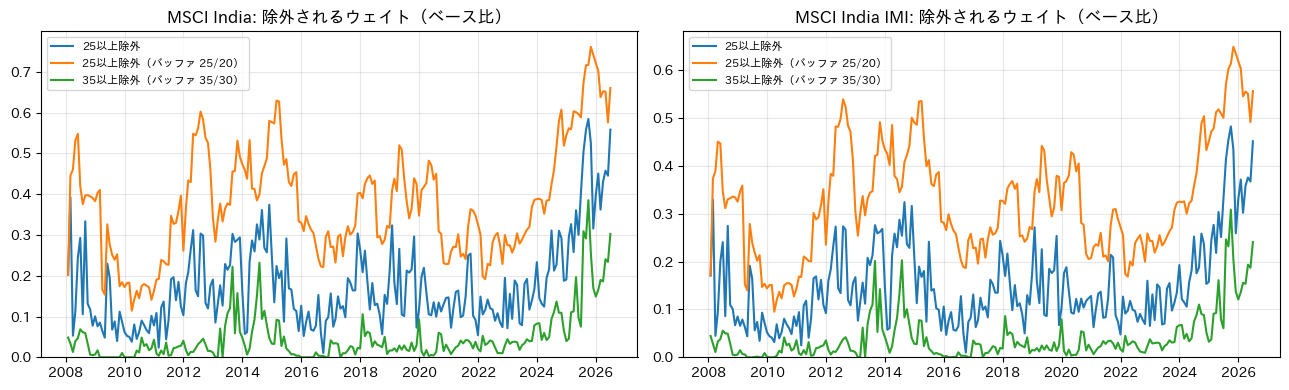

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (b, s), col in w_excluded.items():
    ax = axes[0] if b == "MSCI India" else axes[1]
    ax.plot(col.index, col, label=s)
for ax, b in zip(axes, bases):
    ax.set_title(f"{b}: 除外されるウェイト（ベース比）")
    ax.set_ylim(0, None)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. 税控除後シミュレーション

各ウェイト系列を FIFO ロット台帳で逐次評価する。ベース自身も同じ手続きで評価し、差分をスクリーンのコストとする。

In [4]:
sims = {k: simulate_after_tax(w, rtn, schedule, cost_buy=COST_BUY, cost_sell=COST_SELL) for k, w in weights.items()}


def summarize(period: tuple) -> pd.DataFrame:
    rows = {}
    for (b, s), sim in sims.items():
        m = sim.monthly.iloc[BURN_IN:]
        lo, hi = period
        m = m.loc[lo:hi]
        base_m = sims[(b, "ベース")].monthly.iloc[BURN_IN:].loc[lo:hi]
        g = performance_summary(m["r_gross"], base_m["r_gross"], m["turnover"])
        tc = performance_summary(m["r_net_tc"])
        net = performance_summary(m["r_net"], base_m["r_net"])
        pos_s = m["gain_short"].clip(lower=0).sum()
        pos_l = m["gain_long"].clip(lower=0).sum()
        rows[(b, s)] = {
            "年率回転率": g["turnover_annual"],
            "グロス年率": g["ann_return"],
            "コスト後年率": tc["ann_return"],
            "税後年率": net["ann_return"],
            "コストドラッグ": g["ann_return"] - tc["ann_return"],
            "税ドラッグ": tc["ann_return"] - net["ann_return"],
            "短期比率": pos_s / (pos_s + pos_l) if pos_s + pos_l > 0 else np.nan,
            "超過(グロス, vs ベース)": g["active_return"],
            "超過(税後, vs ベース)": net["active_return"],
            "TE(vs ベース)": g["tracking_error"],
            "IR(税後)": net["information_ratio"],
            "清算時税額/価値（期末）": m["liquidation_tax"].iloc[-1] / m["value"].iloc[-1],
            "月数": len(m),
        }
    df = pd.DataFrame(rows).T
    df.index.names = ["ベース", "スクリーン"]
    return df


for pname, per in PERIODS.items():
    print(f"=== {pname}")
    display(summarize(per).round(4))

=== 全期間


年率回転率   グロス年率  コスト後年率    税後年率  コストドラッグ   税ドラッグ    短期比率  超過(グロス, vs ベース)  超過(税後, vs ベース)  TE(vs ベース)  IR(税後)  清算時税額/価値（期末）     月数
ベース            スクリーン                                                                                                                                                
MSCI India     ベース                 0.1172  0.1419  0.1414  0.1374   0.0005  0.0040  0.0146           0.0000          0.0000      0.0000     NaN        0.0697  210.0
               25以上除外              1.4276  0.1456  0.1391  0.1278   0.0065  0.0113  0.4396           0.0032         -0.0089      0.0231 -0.3634        0.0025  210.0
               25以上除外（バッファ 25/20）  0.9991  0.1470  0.1425  0.1318   0.0046  0.0106  0.3448           0.0039         -0.0057      0.0379 -0.1487        0.0052  210.0
               35以上除外（バッファ 35/30）  0.4422  0.1425  0.1405  0.1326   0.0020  0.0079  0.0844           0.0006         -0.0043      0.0089 -0.4046        0.0062  210.0
MSCI India IMI ベース                 0.1239  0.1483  0.1478  0.1440   0.0006  0.0038  0.0200           0.0000          0.0000      0.0000     NaN        0.0740  210.0
               25以上除外              1.2109  0.1535  0.1479  0.1370   0.0056  0.0109  0.3519           0.0045         -0.0065      0.0189 -0.3205        0.0069  210.0
               25以上除外（バッファ 25/20）  0.8330  0.1539  0.1501  0.1399   0.0038  0.0102  0.2535           0.0046         -0.0040      0.0308 -0.1288        0.0093  210.0
               35以上除外（バッファ 35/30）  0.3966  0.1497  0.1479  0.1402   0.0018  0.0076  0.0744           0.0012         -0.0033      0.0076 -0.3666        0.0166  210.0

=== 前期 〜2017


年率回転率   グロス年率  コスト後年率    税後年率  コストドラッグ   税ドラッグ    短期比率  超過(グロス, vs ベース)  超過(税後, vs ベース)  TE(vs ベース)  IR(税後)  清算時税額/価値（期末）     月数
ベース            スクリーン                                                                                                                                                
MSCI India     ベース                 0.1228  0.1639  0.1634  0.1633   0.0006  0.0000  0.0293           0.0000          0.0000      0.0000     NaN        0.0013  108.0
               25以上除外              1.3412  0.1811  0.1747  0.1694   0.0063  0.0054  0.4257           0.0146          0.0049      0.0234  0.2045        0.0089  108.0
               25以上除外（バッファ 25/20）  0.9599  0.1959  0.1913  0.1867   0.0046  0.0046  0.3558           0.0265          0.0191      0.0379  0.4994        0.0091  108.0
               35以上除外（バッファ 35/30）  0.3882  0.1666  0.1648  0.1639   0.0018  0.0009  0.1666           0.0024          0.0005      0.0082  0.0559        0.0039  108.0
MSCI India IMI ベース                 0.1349  0.1742  0.1736  0.1736   0.0006  0.0000  0.0342           0.0000          0.0000      0.0000     NaN        0.0017  108.0
               25以上除外              1.1709  0.1915  0.1859  0.1814   0.0056  0.0045  0.3726           0.0145          0.0064      0.0192  0.3242        0.0093  108.0
               25以上除外（バッファ 25/20）  0.8306  0.2045  0.2005  0.1966   0.0040  0.0039  0.3060           0.0249          0.0187      0.0294  0.6285        0.0089  108.0
               35以上除外（バッファ 35/30）  0.3703  0.1771  0.1754  0.1745   0.0017  0.0009  0.1451           0.0025          0.0008      0.0071  0.1130        0.0040  108.0

=== 後期 2018〜


年率回転率   グロス年率  コスト後年率    税後年率  コストドラッグ   税ドラッグ    短期比率  超過(グロス, vs ベース)  超過(税後, vs ベース)  TE(vs ベース)  IR(税後)  清算時税額/価値（期末）     月数
ベース            スクリーン                                                                                                                                                
MSCI India     ベース                 0.1113  0.1190  0.1185  0.1106   0.0005  0.0079  0.0117           0.0000          0.0000      0.0000     NaN        0.0697  102.0
               25以上除外              1.5191  0.1093  0.1025  0.0855   0.0068  0.0171  0.4453          -0.0089         -0.0236      0.0225 -0.9549        0.0025  102.0
               25以上除外（バッファ 25/20）  1.0405  0.0975  0.0929  0.0765   0.0046  0.0164  0.3396          -0.0199         -0.0319      0.0368 -0.8641        0.0052  102.0
               35以上除外（バッファ 35/30）  0.4993  0.1175  0.1152  0.1003   0.0023  0.0149  0.0674          -0.0013         -0.0094      0.0096 -0.7557        0.0062  102.0
MSCI India IMI ベース                 0.1122  0.1216  0.1210  0.1135   0.0005  0.0075  0.0167           0.0000          0.0000      0.0000     NaN        0.0740  102.0
               25以上除外              1.2533  0.1146  0.1090  0.0918   0.0056  0.0172  0.3445          -0.0062         -0.0201      0.0182 -0.9976        0.0069  102.0
               25以上除外（バッファ 25/20）  0.8356  0.1027  0.0990  0.0828   0.0037  0.0162  0.2323          -0.0169         -0.0281      0.0312 -0.8959        0.0093  102.0
               35以上除外（バッファ 35/30）  0.4244  0.1213  0.1194  0.1050   0.0019  0.0144  0.0600          -0.0001         -0.0077      0.0081 -0.7346        0.0166  102.0

### 3. スクリーンの純コスト

ベースに対する差分で整理する。「税ドラッグの増分」がスクリーンによって追加で失うリターン、
「超過(税後)」がグロスの効果（前期は正・後期は負）を含めた最終的な損益。

ベースとの差分（全期間）


年率回転率  コストドラッグ   税ドラッグ  超過(グロス, vs ベース)  超過(税後, vs ベース)  TE(vs ベース)
ベース            スクリーン                                                                                   
MSCI India     ベース                 0.0000   0.0000  0.0000           0.0000          0.0000      0.0000
               25以上除外              1.3104   0.0060  0.0073           0.0032         -0.0089      0.0231
               25以上除外（バッファ 25/20）  0.8819   0.0040  0.0067           0.0039         -0.0057      0.0379
               35以上除外（バッファ 35/30）  0.3250   0.0015  0.0040           0.0006         -0.0043      0.0089
MSCI India IMI ベース                 0.0000   0.0000  0.0000           0.0000          0.0000      0.0000
               25以上除外              1.0871   0.0050  0.0071           0.0045         -0.0065      0.0189
               25以上除外（バッファ 25/20）  0.7092   0.0033  0.0064           0.0046         -0.0040      0.0308
               35以上除外（バッファ 35/30）  0.2727   0.0013  0.0038           0.0012         -0.0033      0.0076

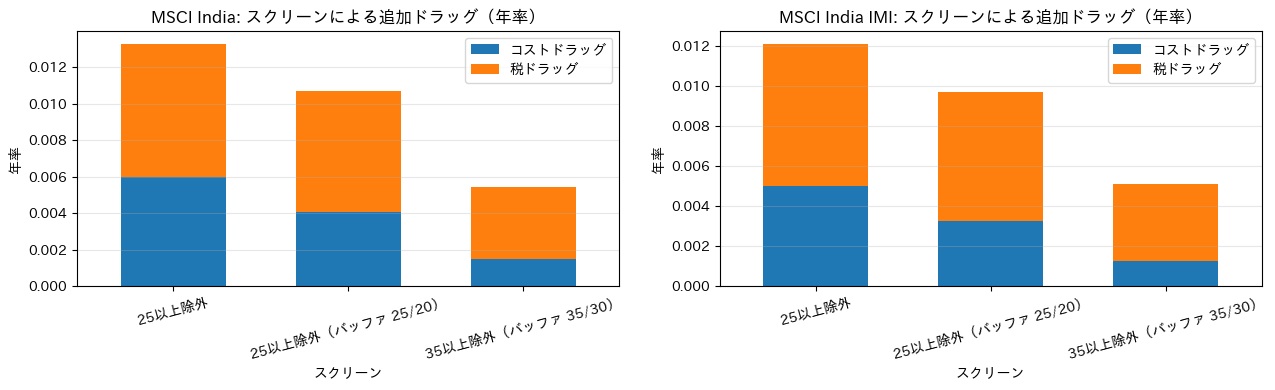

In [5]:
full = summarize(PERIODS["全期間"])
delta = full.groupby(level="ベース", group_keys=False).apply(lambda d: d.sub(d.loc[(d.name, "ベース")]))
cols = ["年率回転率", "コストドラッグ", "税ドラッグ", "超過(グロス, vs ベース)", "超過(税後, vs ベース)", "TE(vs ベース)"]
print("ベースとの差分（全期間）"); display(delta[cols].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, b in zip(axes, bases):
    d = delta.loc[b].drop("ベース")
    d[["コストドラッグ", "税ドラッグ"]].plot.bar(ax=ax, stacked=True, width=0.6)
    ax.set_title(f"{b}: スクリーンによる追加ドラッグ（年率）")
    ax.set_ylabel("年率")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

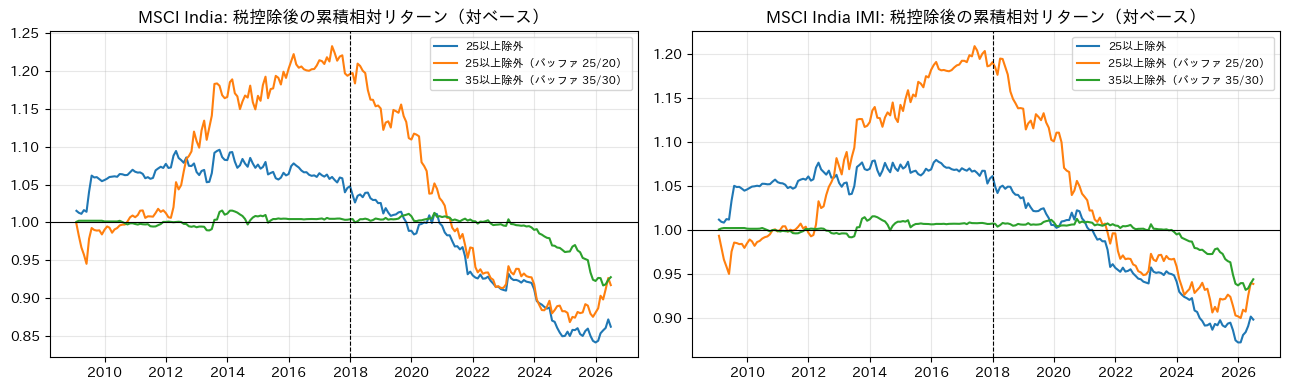

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, b in zip(axes, bases):
    base_net = sims[(b, "ベース")].monthly["r_net"].iloc[BURN_IN:]
    for s in SCREENS:
        if s == "ベース":
            continue
        r = sims[(b, s)].monthly["r_net"].iloc[BURN_IN:]
        rel = (1 + r).cumprod() / (1 + base_net.reindex(r.index)).cumprod()
        ax.plot(rel.index, rel, label=s)
    ax.axhline(1, color="k", linewidth=0.8)
    ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
    ax.set_title(f"{b}: 税控除後の累積相対リターン（対ベース）")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. 年次表（MSCI India ベース、25 以上除外 バッファなし vs 付き）

税務年度ごとの回転率・税額・短期比率。

In [7]:
for s in ["25以上除外", "25以上除外（バッファ 25/20）"]:
    print(f"=== MSCI India / {s}")
    display(sims[("MSCI India", s)].annual[["r_gross", "r_net_tc", "r_net", "turnover", "cost", "tax", "short_ratio"]].round(4))

=== MSCI India / 25以上除外


,r_gross,r_net_tc,r_net,turnover,cost,tax,short_ratio
fiscal_year,,,,,,,
2007,-0.1239,-0.1264,-0.1264,0.7155,0.0042,0.0000,NaN
2008,-0.3894,-0.3927,-0.3927,1.3567,0.0041,0.0000,1.0000
2009,1.0030,0.9968,0.9968,0.7794,0.0028,0.0000,0.7334
2010,0.0975,0.0944,0.0944,0.7204,0.0032,0.0000,0.1151
2011,-0.0659,-0.0708,-0.0708,1.3226,0.0055,0.0000,0.2000
2012,0.0813,0.0729,0.0729,1.9549,0.0086,0.0000,0.2732
2013,0.2074,0.1996,0.1884,1.6138,0.0082,0.0123,0.4623
2014,0.2988,0.2879,0.2644,2.1027,0.0139,0.0302,0.4971
2015,-0.0800,-0.0857,-0.0857,1.5598,0.0102,0.0000,0.1349


=== MSCI India / 25以上除外（バッファ 25/20）


,r_gross,r_net_tc,r_net,turnover,cost,tax,short_ratio
fiscal_year,,,,,,,
2007,-0.1286,-0.1298,-0.1298,0.3462,0.0029,0.0000,NaN
2008,-0.4152,-0.4179,-0.4179,1.1145,0.0030,0.0000,1.0000
2009,0.9484,0.9428,0.9428,0.7221,0.0024,0.0000,0.6900
2010,0.1250,0.1231,0.1231,0.4233,0.0018,0.0000,0.0657
2011,-0.0839,-0.0876,-0.0876,0.9934,0.0039,0.0000,0.1122
2012,0.2203,0.2139,0.2139,1.3086,0.0060,0.0000,0.2724
2013,0.2377,0.2320,0.2138,1.1401,0.0062,0.0200,0.5516
2014,0.3125,0.3069,0.2886,1.0751,0.0075,0.0251,0.4500
2015,-0.0644,-0.0692,-0.0692,1.2940,0.0093,-0.0000,0.1288


### 5. 所見

**除外の規模**

| MSCI India ベース | 25 以上除外 | 25 以上除外（バッファ 25/20） | 35 以上除外（35/30） |
| --- | --- | --- | --- |
| 除外銘柄数（平均） | 13.8 | 29.5 | 4.1 |
| 除外ウェイト（時価総額比） | 17.6% | 37.8% | 4.7% |

- RRI 25 以上は超大型に偏る（`03`）ため、銘柄数は 14 でも時価総額では **17.6%** を除外することになる。
- バッファ付き（除外後は 20 未満になるまで復帰しない）は、20〜25 を行き来する大型株が除外されたままになり、
  除外ウェイトが 38% に膨らむ。回転率を抑える代償として TE が 2.3% → 3.8% に上がる。
  **除外スクリーンではバッファより閾値の引き上げ（35）の方が筋が良い**（除外 4.7%、TE 0.9%）。

**回転率・コスト・税（MSCI India ベース、全期間、バーンイン 12 か月後）**

| | ベース | 25 以上除外 | バッファ 25/20 | 35 以上除外 |
| --- | --- | --- | --- | --- |
| 年率回転率（片道） | 12% | 143% | 100% | 44% |
| コストドラッグ | 0.05% | 0.65% | 0.46% | 0.20% |
| 税ドラッグ | 0.40% | 1.13% | 1.06% | 0.79% |
| 短期比率 | 1% | 44% | 34% | 8% |
| 超過（グロス、対ベース） | — | +0.32% | +0.39% | +0.06% |
| 超過（税後、対ベース） | — | **−0.89%** | −0.57% | −0.43% |
| TE（対ベース） | — | 2.3% | 3.8% | 0.9% |
| 期末の清算時税額 / 価値 | 7.0% | 0.3% | 0.5% | 0.6% |

- 25 以上の除外は年率回転率を 12% → 143% に引き上げ、追加のドラッグはコスト 0.6% + 税 0.7% = **年率 1.3%**。
  グロスの超過（全期間 +0.3%）を打ち消して税後は −0.9%。
- 実現益の 44% が短期（STCG 23.92%）。閾値近傍の出入りで 12 か月未満の売却が多い。
- ベースは含み益を抱えたまま（清算時税額が価値の 7%）なのに対し、スクリーン版は途中で実現して納税済み
  （0.3〜0.6%）。税の繰延効果を失う点でも不利。
- 前期（〜2017）は LTCG 非課税（2018-03 まで）だったため税ドラッグは 0.5% に留まり、グロスの効果（+1.5〜2.7%）で
  税後も +0.5〜1.9% の超過があった。後期（2018〜）は LTCG 課税復活と効果消失が重なり、税ドラッグ 1.7%（ベース 0.8%）、
  税後超過 **−2.4%**（バッファ付き −3.2%）。
- IMI ベースでも同じ構図（25 以上除外の税後超過 −0.65%、後期 −2.0%）。

**判断への含意**

1. 25 以上の一律除外は、リターン根拠が無い（`06`〜`08`）うえに年率 1.3% の追加ドラッグと 2.3% の TE を伴う。
   採用するなら ESG 方針としての要請であることを明確にし、コストとして年率 1% 超を見込む。
2. 除外を課す場合の設計は「閾値を高くする（35 以上）」が最もコスト効率が良い（追加ドラッグ 0.55%、TE 0.9%）。
   バッファは回転率を下げるが除外幅と TE を広げるため、除外スクリーンには向かない。
3. 除外による売却は 12 か月未満のロットに当たりやすい。実運用ではロット単位で「12 か月超になるまで売却を待つ」
   判断（`docs/india_tcg.md` §2.5）を組み合わせれば短期比率を下げられるが、その分除外の即時性は失われる。